# Step 3B - Counterfactual Perturbation with Data-driven Targets

从上一步自动筛选结果中取前 N 个候选，直接传给 Step3。

- 不使用预设靶点列表
- 输入完全来自 `03_data_driven_target_selection.ipynb` 产物

In [ ]:
from pathlib import Path
import subprocess
import pandas as pd

ROOT = Path.cwd().resolve().parent.parent if Path.cwd().name == "example_sccrc_icb_step_by_step" else Path.cwd().resolve()
STEP1 = ROOT / "results" / "examples" / "sccrc_icb" / "step1"
STEP2 = ROOT / "results" / "examples" / "sccrc_icb" / "step2"
STEP3 = ROOT / "results" / "examples" / "sccrc_icb" / "step3"
STEP3.mkdir(parents=True, exist_ok=True)

rank_path = STEP3 / "data_driven_targets_top20.csv"
if not rank_path.exists():
    raise FileNotFoundError(f"Missing ranking file: {rank_path}")

ranked = pd.read_csv(rank_path)
target_top_n = 3
targets = ranked["gene"].head(target_top_n).tolist()
if len(targets) == 0:
    raise RuntimeError("No targets selected from data-driven ranking.")

target_arg = ",".join(targets)
print("Data-driven targets:", targets)

cmd = [
    "python", "scripts/run_step3.py",
    "--step1-dir", str(STEP1),
    "--step2-dir", str(STEP2),
    "--output-dir", str(STEP3),
    "--fig-dir", str(ROOT / "results" / "figures" / "examples" / "sccrc_icb" / "step3"),
    "--method", "latent_arithmetic",
    "--targets", target_arg,
    "--target-top-k", "30",
    "--device", "cpu",
]
print(" ".join(cmd))
subprocess.run(cmd, cwd=ROOT, check=True)
print(f"Step3 done -> {STEP3}")

Step3 summary figure generated locally


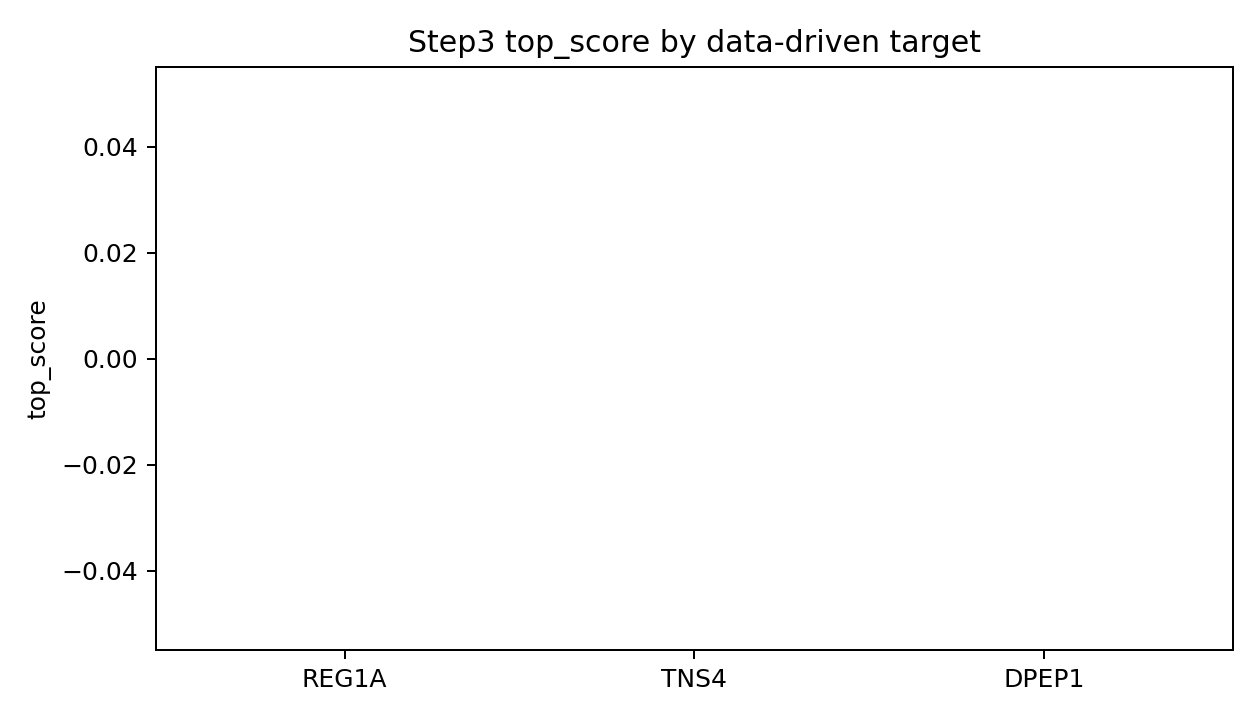

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

metrics = json.loads((STEP3 / "step3_metrics.json").read_text(encoding="utf-8"))
targets = metrics.get("targets", [])
per = metrics.get("per_target", {})

rows = []
for g in targets:
    m = per.get(g, {})
    rows.append({
        "gene": g,
        "n_candidates": m.get("n_candidates", 0),
        "top_score": m.get("top_score", 0.0),
        "cf_r2_mean": (m.get("cf_quality") or {}).get("r2_mean", None),
    })
summary = pd.DataFrame(rows)
display(summary)

if not summary.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(summary["gene"], summary["top_score"])
    ax.set_title("Step3 top_score by data-driven target")
    ax.set_ylabel("top_score")
    plt.tight_layout()
    plt.show()